In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
#Load CIFAR-10 Dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3076s 18us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


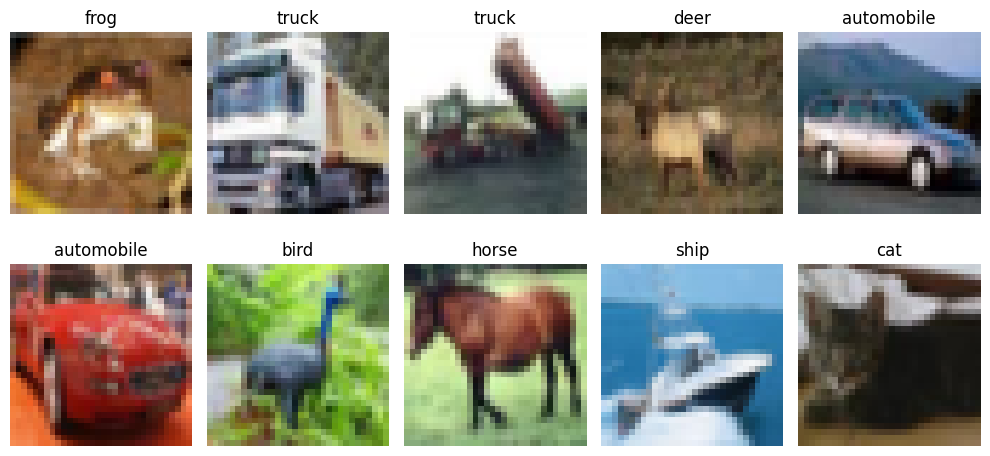

In [3]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
#Normalize images
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

**ANN Model**

In [5]:
#ANN baseline model
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

#Compile ANN
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Train ANN (10 Epochs)
ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2727 - loss: 1.9802 - val_accuracy: 0.3374 - val_loss: 1.8420
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3106 - loss: 1.8753 - val_accuracy: 0.3720 - val_loss: 1.7732
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.3395 - loss: 1.8110 - val_accuracy: 0.4016 - val_loss: 1.7192
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - accuracy: 0.3569 - loss: 1.7705 - val_accuracy: 0.4066 - val_loss: 1.7122
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3674 - loss: 1.7398 - val_accuracy: 0.3992 - val_loss: 1.6964
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3777 - loss: 1.7213 - val_accuracy: 0.4074 - val_loss: 1.6591
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.3829 - loss: 1.6997 - val_accuracy: 0.4090 - val_loss: 1.6763
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3906 - loss: 1.6899 - 

In [6]:
#Evaluation
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4252 - loss: 1.6280
ANN Test Accuracy: 0.4251999855041504


**CNN Model**

In [7]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 128ms/step - accuracy: 0.4604 - loss: 1.5010 - val_accuracy: 0.5094 - val_loss: 1.3733
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 125ms/step - accuracy: 0.6028 - loss: 1.1274 - val_accuracy: 0.6072 - val_loss: 1.0989
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 128ms/step - accuracy: 0.6707 - loss: 0.9532 - val_accuracy: 0.6280 - val_loss: 1.0875
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.7140 - loss: 0.8252 - val_accuracy: 0.6600 - val_loss: 0.9968
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 140s 125ms/step - accuracy: 0.7417 - loss: 0.7406 - val_accuracy: 0.5860 - val_loss: 1.3385
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 125ms/step - accuracy: 0.7682 - loss: 0.6595 - val_accuracy: 0.6778 - val_loss: 0.9824
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.7924 - loss: 0.5944 - val_accuracy: 0.6010 - val_loss: 1.2049
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.8105 - lo

In [9]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7444 - loss: 0.8433
CNN Test Accuracy: 0.7444000244140625


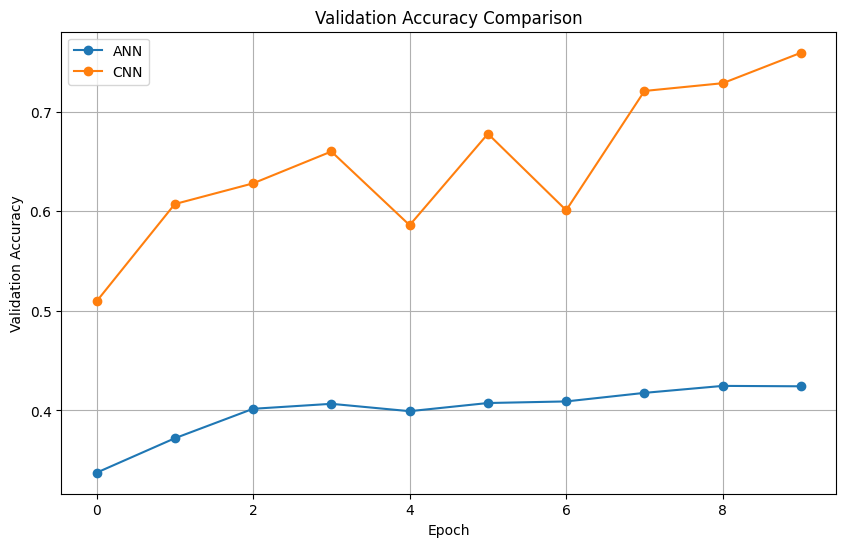

In [8]:
plt.figure(figsize=(10,6))

plt.plot(ann_history.history['val_accuracy'],
         marker='o',
         label='ANN')

plt.plot(cnn_history.history['val_accuracy'],
         marker='o',
         label='CNN')

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Training the advanced CNN model

In [11]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])


In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=5,

    restore_best_weights=True

)

In [14]:
aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32,(3,3),padding='same',activation='relu',
           input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10,activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

In [17]:
history_aug = aug_cnn_model.fit(

    x_train,
    y_train,

    validation_data=(x_test,y_test),

    epochs=20,

    batch_size=64,

    callbacks=[early_stop],

    verbose=1

)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 191s 244ms/step - accuracy: 0.7311 - loss: 0.8202 - val_accuracy: 0.7168 - val_loss: 0.8182
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 190s 242ms/step - accuracy: 0.7321 - loss: 0.8147 - val_accuracy: 0.7141 - val_loss: 0.8740
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 238ms/step - accuracy: 0.7388 - loss: 0.7977 - val_accuracy: 0.6981 - val_loss: 0.9183
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 184s 235ms/step - accuracy: 0.7377 - loss: 0.7938 - val_accuracy: 0.7271 - val_loss: 0.8201
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 186s 238ms/step - accuracy: 0.7445 - loss: 0.7847 - val_accuracy: 0.7614 - val_loss: 0.7101
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.7473 - loss: 0.7697 - val_accuracy: 0.7448 - val_loss: 0.7535
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.7530 - loss: 0.7647 - val_accuracy: 0.7547 - val_loss: 0.7456
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.7541 -

In [20]:
test_loss, test_accuracy = aug_cnn_model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - accuracy: 0.7834 - loss: 0.6549
Test Loss: 0.6548752188682556
Test Accuracy: 0.7833999991416931
Test Accuracy: 78.34%


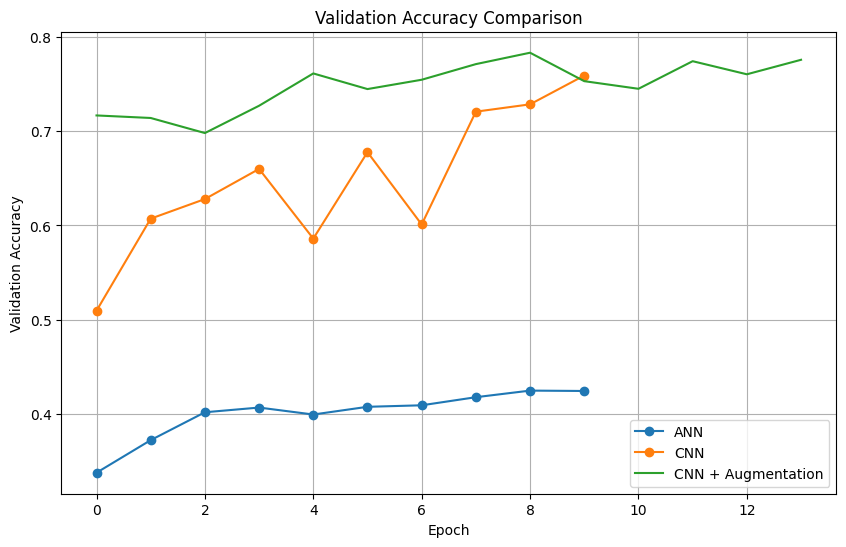

In [18]:
plt.figure(figsize=(10,6))

plt.plot(ann_history.history['val_accuracy'],
         marker='o',
         label="ANN")

plt.plot(cnn_history.history['val_accuracy'],
         marker='o',
         label="CNN")

plt.plot(history_aug.history['val_accuracy'],
         label="CNN + Augmentation")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [21]:
#ANN model with increased layers.

ann_model_2 = models.Sequential([

    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
ann_model_2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
history_ann_2 = ann_model_2.fit(

    x_train_flat,
    y_train,

    validation_data=(x_test_flat,y_test),

    epochs=10,
    batch_size=64,
    verbose=1

)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 36ms/step - accuracy: 0.2136 - loss: 2.0948 - val_accuracy: 0.3034 - val_loss: 1.9298
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.2528 - loss: 1.9851 - val_accuracy: 0.2934 - val_loss: 1.9322
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2736 - loss: 1.9410 - val_accuracy: 0.3256 - val_loss: 1.8954
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2779 - loss: 1.9291 - val_accuracy: 0.3410 - val_loss: 1.8743
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.2913 - loss: 1.9086 - val_accuracy: 0.3471 - val_loss: 1.8661
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2931 - loss: 1.8974 - val_accuracy: 0.3351 - val_loss: 1.8701
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.2989 - loss: 1.8853 - val_accuracy: 0.3187 - val_loss: 1.8816
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.3040 - loss: 1.8797 - 

In [25]:
#Evaluation
ann_test_loss, ann_test_acc = ann_model_2.evaluate(x_test_flat, y_test)
print("ANN 2 Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3756 - loss: 1.7850
ANN 2 Test Accuracy: 0.37560001015663147


In [28]:
#Overall evaluation

ann_loss, ann_acc = ann_model.evaluate(x_test_flat,y_test)

ann_loss_2, ann_acc_2 = ann_model_2.evaluate(x_test_flat,y_test)

cnn_loss, cnn_acc = cnn_model.evaluate(x_test_norm,y_test)

aug_loss, aug_acc = aug_cnn_model.evaluate(x_test,y_test)

print("ANN Accuracy :", ann_acc)

print("ANN 2 Accuracy :", ann_acc_2)

print("CNN Accuracy :", cnn_acc)

print("Augmented CNN Accuracy :", aug_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4252 - loss: 1.6280
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3756 - loss: 1.7850
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.7444 - loss: 0.8433
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7834 - loss: 0.6549
ANN Accuracy : 0.4251999855041504
ANN 2 Accuracy : 0.37560001015663147
CNN Accuracy : 0.7444000244140625
Augmented CNN Accuracy : 0.7833999991416931


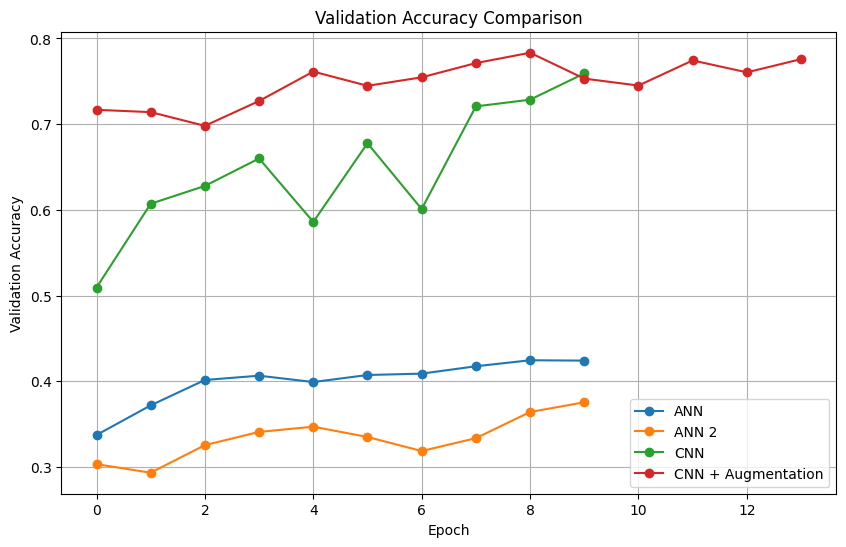

In [26]:
from re import M
plt.figure(figsize=(10,6))

plt.plot(ann_history.history['val_accuracy'],
         marker='o',
         label="ANN")

plt.plot(history_ann_2.history['val_accuracy'],
         marker='o',
         label="ANN 2")

plt.plot(cnn_history.history['val_accuracy'],
         marker='o',
         label="CNN")

plt.plot(history_aug.history['val_accuracy'],
         marker='o',
         label="CNN + Augmentation")

plt.xlabel("Epoch")

plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Comparison")

plt.legend()

plt.grid(True)

plt.show()



*   The experiment demonstrates that CNNs outperform ANNs for image classification because they preserve and exploit spatial information in images.
*   Incorporating data augmentation, larger convolutional filter banks, deeper dense layers, longer training (20 epochs), and EarlyStopping further improves robustness and validation performance, making the augmented CNN the most effective architecture among the three evaluated models.